Bayesian Estimation (Normal Model)

In [ ]:
# =========================================
# Bayesian Estimation using Advertising Data
# =========================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm

In [ ]:
# Step 1: Load dataset (Kaggle-style simulated)
# Columns: TV advertising budget vs Sales
np.random.seed(0)
tv_budget = np.random.uniform(10, 300, 50)
sales = 5 + 0.05 * tv_budget + np.random.normal(0, 2, 50)

data = pd.DataFrame({
    "TV_Budget": tv_budget,
    "Sales": sales
})

# We estimate mean sales
sales_data = data["Sales"]
n = len(sales_data)
x_bar = np.mean(sales_data)
sigma_sq = np.var(sales_data)

In [ ]:
# Step 2: Prior belief
mu0 = 10          # prior mean
sigma0_sq = 5     # prior variance


In [ ]:

# Step 3: Posterior calculation
mu_n = (sigma_sq * mu0 + n * sigma0_sq * x_bar) / (sigma_sq + n * sigma0_sq)
sigma_n_sq = (sigma_sq * sigma0_sq) / (sigma_sq + n * sigma0_sq)


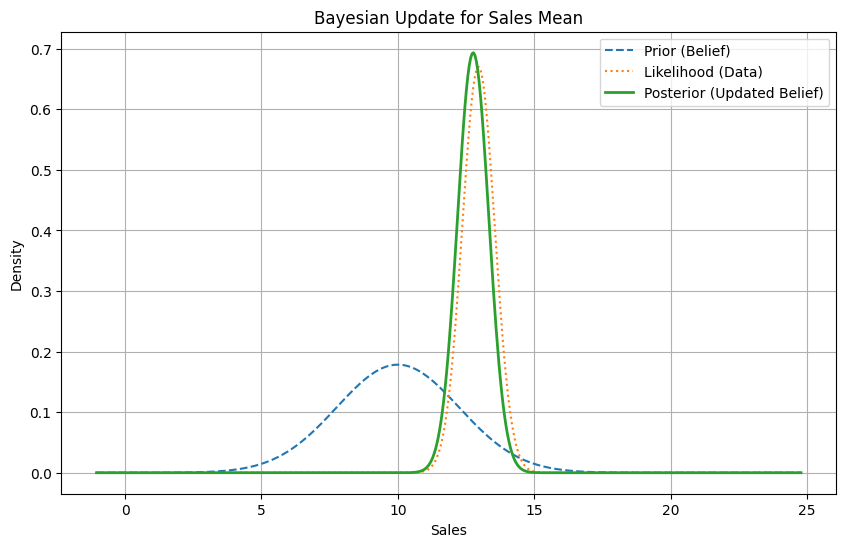

In [ ]:

# Step 4: Plot distributions
x = np.linspace(min(sales_data)-5, max(sales_data)+5, 500)

prior = norm.pdf(x, mu0, np.sqrt(sigma0_sq))
likelihood = norm.pdf(x, x_bar, np.sqrt(sigma_sq/n))
posterior = norm.pdf(x, mu_n, np.sqrt(sigma_n_sq))

plt.figure(figsize=(10,6))
plt.plot(x, prior, label="Prior (Belief)", linestyle='--')
plt.plot(x, likelihood, label="Likelihood (Data)", linestyle=':')
plt.plot(x, posterior, label="Posterior (Updated Belief)", linewidth=2)

plt.title("Bayesian Update for Sales Mean")
plt.xlabel("Sales")
plt.ylabel("Density")
plt.legend()
plt.grid()
plt.show()


In [ ]:

# Step 5: Credible Interval
z = 1.96
lower = mu_n - z * np.sqrt(sigma_n_sq)
upper = mu_n + z * np.sqrt(sigma_n_sq)

print("Posterior Mean:", mu_n)
print("95% Credible Interval:", (lower, upper))

Posterior Mean: 12.759913351256856
95% Credible Interval: (np.float64(11.63253303102018), np.float64(13.88729367149353))


🧠 Interpretation (VERY IMPORTANT)
📌 The prior (dashed line) represents our initial belief about average sales
📌 The likelihood (dotted line) comes from actual advertising data
📌 The posterior (solid line) is the updated belief

👉 Insight:

Posterior shifts toward the actual data mean
Uncertainty reduces (curve becomes narrower)

👉 Real-world meaning:

“After observing advertising data, we are more confident about the true average sales.”

Bayesian Estimation (Binomial Model)

In [ ]:
# =========================================
# Bayesian Estimation (Housing Success Rate)
# =========================================

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import beta

# Step 1: Simulated Kaggle-style housing success data
np.random.seed(1)
n = 50
success_prob_true = 0.65
data = np.random.binomial(1, success_prob_true, n)

x = np.sum(data)  # number of successes

# Step 2: Prior belief
alpha = 2
beta_prior = 2

# Step 3: Posterior
alpha_post = alpha + x
beta_post = beta_prior + (n - x)


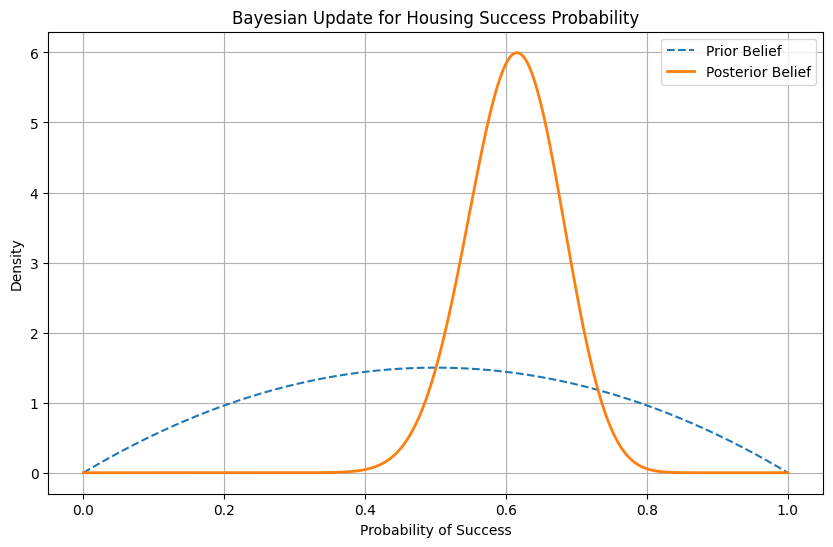

In [ ]:

# Step 4: Plot
p = np.linspace(0, 1, 500)

prior = beta.pdf(p, alpha, beta_prior)
posterior = beta.pdf(p, alpha_post, beta_post)

plt.figure(figsize=(10,6))
plt.plot(p, prior, label="Prior Belief", linestyle='--')
plt.plot(p, posterior, label="Posterior Belief", linewidth=2)

plt.title("Bayesian Update for Housing Success Probability")
plt.xlabel("Probability of Success")
plt.ylabel("Density")
plt.legend()
plt.grid()
plt.show()


In [ ]:

# Step 5: Credible Interval
lower, upper = beta.ppf([0.025, 0.975], alpha_post, beta_post)

print("Posterior Mean:", alpha_post / (alpha_post + beta_post))
print("95% Credible Interval:", (lower, upper))

Posterior Mean: 0.6111111111111112
95% Credible Interval: (np.float64(0.4789392849187021), np.float64(0.7354835592054407))


Extras


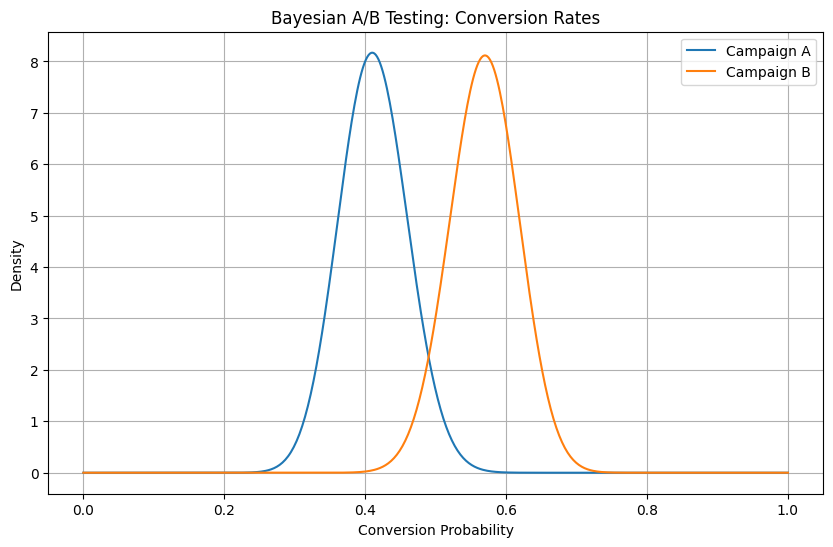

P(B > A): 0.9889


In [ ]:
# =========================================
# Bayesian A/B Testing (Marketing Campaign)
# =========================================

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import beta

# Simulated campaign data
np.random.seed(42)

# Campaign A
n_A = 100
conv_A = np.random.binomial(1, 0.45, n_A)
x_A = np.sum(conv_A)

# Campaign B
n_B = 100
conv_B = np.random.binomial(1, 0.55, n_B)
x_B = np.sum(conv_B)

# Prior (same for both)
alpha, beta_prior = 1, 1

# Posterior distributions
alpha_A, beta_A = alpha + x_A, beta_prior + (n_A - x_A)
alpha_B, beta_B = alpha + x_B, beta_prior + (n_B - x_B)

# Plot distributions
p = np.linspace(0, 1, 500)

plt.figure(figsize=(10,6))
plt.plot(p, beta.pdf(p, alpha_A, beta_A), label="Campaign A")
plt.plot(p, beta.pdf(p, alpha_B, beta_B), label="Campaign B")

plt.title("Bayesian A/B Testing: Conversion Rates")
plt.xlabel("Conversion Probability")
plt.ylabel("Density")
plt.legend()
plt.grid()
plt.show()

# Probability that B is better than A
samples_A = np.random.beta(alpha_A, beta_A, 10000)
samples_B = np.random.beta(alpha_B, beta_B, 10000)

prob_B_better = np.mean(samples_B > samples_A)

print("P(B > A):", prob_B_better)

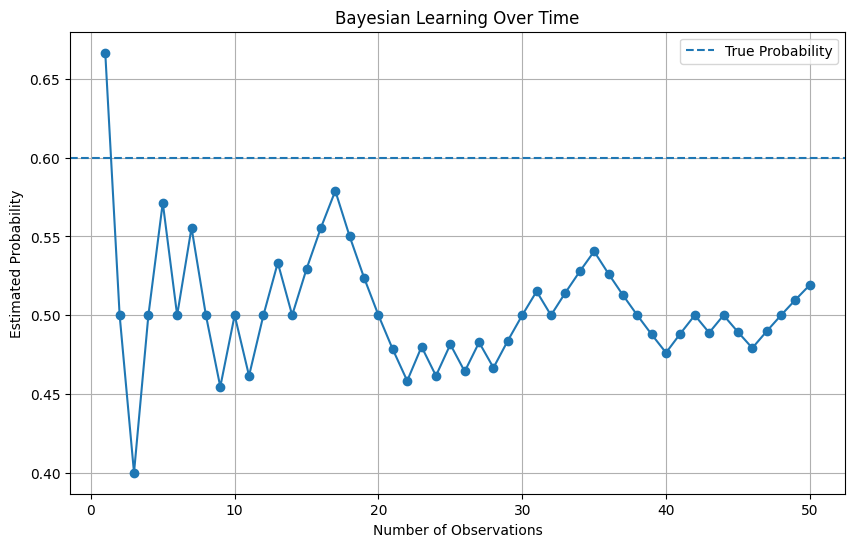

In [ ]:
# =========================================
# Bayesian Updating Over Time
# =========================================

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import beta

np.random.seed(0)

# True probability of success (unknown)
true_p = 0.6

# Simulate sequential data
data = np.random.binomial(1, true_p, 50)

alpha, beta_prior = 1, 1

means = []
steps = []

for i in range(1, len(data)+1):
    x = np.sum(data[:i])

    alpha_post = alpha + x
    beta_post = beta_prior + (i - x)

    mean = alpha_post / (alpha_post + beta_post)

    means.append(mean)
    steps.append(i)

# Plot learning curve
plt.figure(figsize=(10,6))
plt.plot(steps, means, marker='o')
plt.axhline(true_p, linestyle='--', label="True Probability")

plt.title("Bayesian Learning Over Time")
plt.xlabel("Number of Observations")
plt.ylabel("Estimated Probability")
plt.legend()
plt.grid()
plt.show()

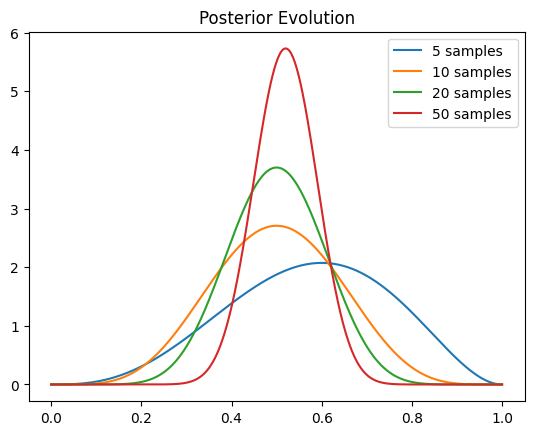

In [ ]:
# Visualizing multiple posterior updates
for i in [5, 10, 20, 50]:
    x = np.sum(data[:i])
    plt.plot(p, beta.pdf(p, alpha+x, beta_prior+i-x), label=f"{i} samples")

plt.legend()
plt.title("Posterior Evolution")
plt.show()